# Lynceus Fraud Detection System

## Exploratory Data Analysis (EDA)

### Objective

Understand the synthetic fraud dataset before any preprocessing or model training.

This notebook **does not**:

- Encode categorical variables
- Scale numerical variables
- Balance classes
- Train models

This notebook focuses solely on understanding the dataset.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

RANDOM_STATE = 42

# Dataset Paths

In [2]:
from pathlib import Path

DATA_DIR = Path("/Users/lakshaydahiya/Desktop/engineerOS/01_projects/lynceus/backend/app/ml/data/synthetic")

TRAIN_PATH = DATA_DIR / "transactions_train.csv"
VAL_PATH = DATA_DIR / "transactions_val.csv"
TEST_PATH = DATA_DIR / "transactions_test.csv"

METADATA_PATH = DATA_DIR / "dataset_metadata.json"
SCHEMA_PATH = DATA_DIR / "schema.json"

# Load Training Dataset

In [4]:
df = pd.read_csv(
    TRAIN_PATH,
    parse_dates=["timestamp"]
)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 70,000
Columns : 23


# Dataset Preview

In [5]:
display(df.head())

,timestamp,amount,currency,payment_method,hour,day_of_week,is_weekend,sender_account_age_days,receiver_account_age_days,sender_txn_count_24h,receiver_txn_count_24h,sender_avg_amount_30d,receiver_avg_amount_30d,is_new_receiver,origin_country,destination_country,merchant_category,device_type,device_trusted,cross_border,high_risk_country,velocity_score,fraud_label
0,2025-01-01 00:02:41,1576.01,GBP,WALLET,0,2,False,371,1779,8,6,1403.72,6761.76,False,GB,GB,SHOPPING,ANDROID,False,False,False,0.12,0
1,2025-01-01 00:07:42,1583.34,INR,WALLET,0,2,False,1524,4916,6,2,1289.12,5601.90,False,IN,IN,UTILITIES,ANDROID,True,False,False,0.08,0
2,2025-01-01 00:28:15,1389.31,INR,WALLET,0,2,False,1382,1751,4,2,1321.68,20624.90,False,IN,IN,SHOPPING,IOS,True,False,False,0.04,0
3,2025-01-01 00:28:53,1859.82,INR,WALLET,0,2,False,1585,2010,8,5,1689.93,10405.24,False,IN,IN,ENTERTAINMENT,ANDROID,True,False,False,0.18,0
4,2025-01-01 00:30:30,1218.01,USD,UPI,0,2,False,179,921,13,20,1324.70,8312.08,False,AE,AE,FOOD,ANDROID,True,False,False,0.26,0


In [6]:
display(df.tail())

,timestamp,amount,currency,payment_method,hour,day_of_week,is_weekend,sender_account_age_days,receiver_account_age_days,sender_txn_count_24h,receiver_txn_count_24h,sender_avg_amount_30d,receiver_avg_amount_30d,is_new_receiver,origin_country,destination_country,merchant_category,device_type,device_trusted,cross_border,high_risk_country,velocity_score,fraud_label
69995,2025-09-12 17:05:45,199.38,GBP,CARD,17,4,False,1331,2059,36,13,1556.47,15295.17,False,GB,GB,FOOD,IOS,False,False,False,0.96,1
69996,2025-09-12 17:06:24,925.89,INR,WALLET,17,4,False,912,612,6,36,1201.43,16684.95,False,IN,IN,UTILITIES,ANDROID,True,False,False,0.05,0
69997,2025-09-12 17:10:21,1292.29,INR,UPI,17,4,False,1366,3734,15,33,1431.51,1593.32,False,IN,IN,ELECTRONICS,ANDROID,True,False,False,0.22,0
69998,2025-09-12 17:12:14,13290.21,INR,CARD,17,4,False,4372,1976,48,18,33098.03,15025.17,False,IN,IN,TRAVEL,WEB,True,False,False,1.00,0
69999,2025-09-12 17:14:22,1035.69,INR,UPI,17,4,False,3162,1244,9,17,3171.27,5510.58,False,IN,IN,ELECTRONICS,WINDOWS,True,False,False,0.12,0


In [7]:
display(df.sample(5, random_state=RANDOM_STATE))

,timestamp,amount,currency,payment_method,hour,day_of_week,is_weekend,sender_account_age_days,receiver_account_age_days,sender_txn_count_24h,receiver_txn_count_24h,sender_avg_amount_30d,receiver_avg_amount_30d,is_new_receiver,origin_country,destination_country,merchant_category,device_type,device_trusted,cross_border,high_risk_country,velocity_score,fraud_label
46730,2025-06-20 13:04:46,1713.04,USD,CARD,13,4,False,2312,1081,6,41,3002.66,3265.29,False,US,US,ENTERTAINMENT,WEB,True,False,False,0.70,0
48393,2025-06-26 19:30:14,4103.16,INR,CARD,19,3,False,2499,1922,5,11,8562.74,12172.05,False,IN,KP,OTHER,LINUX,True,True,True,0.12,0
41416,2025-06-01 16:04:11,7462.83,INR,CARD,16,6,True,3110,3407,41,26,7314.71,10684.87,False,IN,IN,UTILITIES,ANDROID,False,False,False,0.10,0
34506,2025-05-05 19:12:44,9679.67,USD,CARD,19,0,False,3438,407,7,26,7670.00,4112.10,False,AE,AE,TRAVEL,MACOS,True,False,False,0.13,0
43725,2025-06-08 17:54:41,1283.30,INR,UPI,17,6,True,307,42,9,34,1066.94,2015.19,True,IN,IN,SHOPPING,ANDROID,False,False,False,0.18,0


# Dataset Dimensions

In [8]:
rows, cols = df.shape

print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

Rows    : 70,000
Columns : 23


# Column Names

In [9]:
for idx, col in enumerate(df.columns, start=1):
    print(f"{idx:02d}. {col}")

01. timestamp
02. amount
03. currency
04. payment_method
05. hour
06. day_of_week
07. is_weekend
08. sender_account_age_days
09. receiver_account_age_days
10. sender_txn_count_24h
11. receiver_txn_count_24h
12. sender_avg_amount_30d
13. receiver_avg_amount_30d
14. is_new_receiver
15. origin_country
16. destination_country
17. merchant_category
18. device_type
19. device_trusted
20. cross_border
21. high_risk_country
22. velocity_score
23. fraud_label


# Dataset Information

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   timestamp                  70000 non-null  datetime64[us]
 1   amount                     70000 non-null  float64       
 2   currency                   70000 non-null  str           
 3   payment_method             70000 non-null  str           
 4   hour                       70000 non-null  int64         
 5   day_of_week                70000 non-null  int64         
 6   is_weekend                 70000 non-null  bool          
 7   sender_account_age_days    70000 non-null  int64         
 8   receiver_account_age_days  70000 non-null  int64         
 9   sender_txn_count_24h       70000 non-null  int64         
 10  receiver_txn_count_24h     70000 non-null  int64         
 11  sender_avg_amount_30d      70000 non-null  float64       
 12  receiver_avg_am

In [11]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Unique Values": df.nunique()
})

display(dtype_df)

,Column,Data Type,Missing Values,Unique Values
timestamp,timestamp,datetime64[us],0,69842
amount,amount,float64,0,67231
currency,currency,str,0,4
payment_method,payment_method,str,0,4
hour,hour,int64,0,24
day_of_week,day_of_week,int64,0,7
is_weekend,is_weekend,bool,0,2
sender_account_age_days,sender_account_age_days,int64,0,5272
receiver_account_age_days,receiver_account_age_days,int64,0,5506
sender_txn_count_24h,sender_txn_count_24h,int64,0,78


# Descriptive Statistics

In [12]:
display(df.describe())

,timestamp,amount,hour,day_of_week,sender_account_age_days,receiver_account_age_days,sender_txn_count_24h,receiver_txn_count_24h,sender_avg_amount_30d,receiver_avg_amount_30d,velocity_score,fraud_label
count,70000,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00
mean,2025-05-08 08:47:09.974942,6195.01,14.39,2.95,1802.43,2446.21,12.90,20.43,7207.30,10251.08,0.25,0.02
min,2025-01-01 00:02:41,3.88,0.00,0.00,1.00,1.00,0.00,0.00,90.71,434.89,0.00,0.00
25%,2025-03-04 22:38:14.750000,1846.33,11.00,1.00,825.00,1164.00,5.00,10.00,1779.59,5341.57,0.10,0.00
50%,2025-05-07 17:46:38,3256.68,15.00,3.00,1443.00,2429.00,10.00,20.00,4915.11,10224.55,0.19,0.00
75%,2025-07-10 19:18:25,7744.92,19.00,5.00,2714.25,3706.00,16.00,31.00,8137.40,15035.97,0.31,0.00
max,2025-09-12 17:14:22,203305.81,23.00,6.00,5920.00,5974.00,78.00,48.00,57546.58,23708.79,1.00,1.00
std,NaN,8160.44,6.00,1.96,1231.24,1482.27,11.49,11.96,8586.93,5682.84,0.22,0.15


In [13]:
display(df.describe(include="object"))

,currency,payment_method,origin_country,destination_country,merchant_category,device_type
count,70000,70000,70000,70000,70000,70000
unique,4,4,8,13,10,6
top,INR,UPI,IN,IN,UTILITIES,ANDROID
freq,52045,26919,53717,50967,13095,21488


In [14]:
display(df.describe(include="all"))

,timestamp,amount,currency,payment_method,hour,day_of_week,is_weekend,sender_account_age_days,receiver_account_age_days,sender_txn_count_24h,receiver_txn_count_24h,sender_avg_amount_30d,receiver_avg_amount_30d,is_new_receiver,origin_country,destination_country,merchant_category,device_type,device_trusted,cross_border,high_risk_country,velocity_score,fraud_label
count,70000,70000.00,70000,70000,70000.00,70000.00,70000,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000,70000,70000,70000,70000,70000,70000,70000,70000.00,70000.00
unique,NaN,NaN,4,4,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,2,8,13,10,6,2,2,2,NaN,NaN
top,NaN,NaN,INR,UPI,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False,IN,IN,UTILITIES,ANDROID,True,False,False,NaN,NaN
freq,NaN,NaN,52045,26919,NaN,NaN,50988,NaN,NaN,NaN,NaN,NaN,NaN,59764,53717,50967,13095,21488,62528,64102,67417,NaN,NaN
mean,2025-05-08 08:47:09.974942,6195.01,NaN,NaN,14.39,2.95,NaN,1802.43,2446.21,12.90,20.43,7207.30,10251.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.25,0.02
min,2025-01-01 00:02:41,3.88,NaN,NaN,0.00,0.00,NaN,1.00,1.00,0.00,0.00,90.71,434.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00
25%,2025-03-04 22:38:14.750000,1846.33,NaN,NaN,11.00,1.00,NaN,825.00,1164.00,5.00,10.00,1779.59,5341.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.00
50%,2025-05-07 17:46:38,3256.68,NaN,NaN,15.00,3.00,NaN,1443.00,2429.00,10.00,20.00,4915.11,10224.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.19,0.00
75%,2025-07-10 19:18:25,7744.92,NaN,NaN,19.00,5.00,NaN,2714.25,3706.00,16.00,31.00,8137.40,15035.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.31,0.00
max,2025-09-12 17:14:22,203305.81,NaN,NaN,23.00,6.00,NaN,5920.00,5974.00,78.00,48.00,57546.58,23708.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00


# Memory Usage

In [16]:
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Dataset Memory Usage: {memory_mb:.2f} MB")

Dataset Memory Usage: 11.67 MB


# Missing Value Analysis

In [17]:
missing_df = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": df.isna().mean() * 100
}).sort_values(by="Missing Count", ascending=False)

display(missing_df)

,Missing Count,Missing Percentage
timestamp,0,0.00
receiver_avg_amount_30d,0,0.00
velocity_score,0,0.00
high_risk_country,0,0.00
cross_border,0,0.00
device_trusted,0,0.00
device_type,0,0.00
merchant_category,0,0.00
destination_country,0,0.00
origin_country,0,0.00


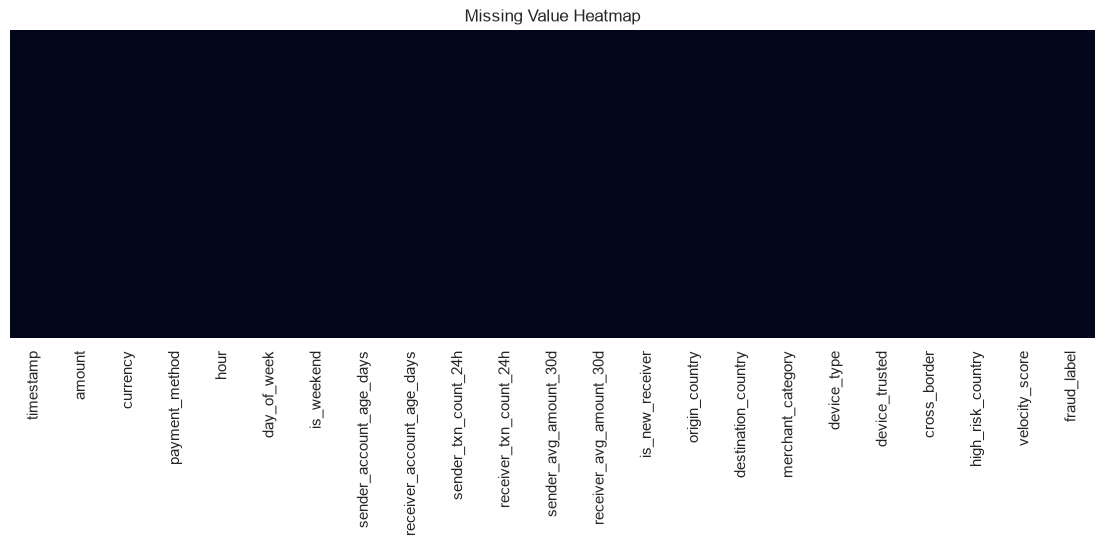

In [18]:
plt.figure(figsize=(14, 4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")

plt.show()

# Duplicate Analysis

In [19]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


# Target Variable Distribution

In [20]:
target_counts = df["fraud_label"].value_counts()

display(target_counts)

fraud_label
0    68431
1     1569
Name: count, dtype: int64

In [21]:
target_percentage = (
    df["fraud_label"]
      .value_counts(normalize=True)
      .mul(100)
)

display(target_percentage)

fraud_label
0   97.76
1    2.24
Name: proportion, dtype: float64

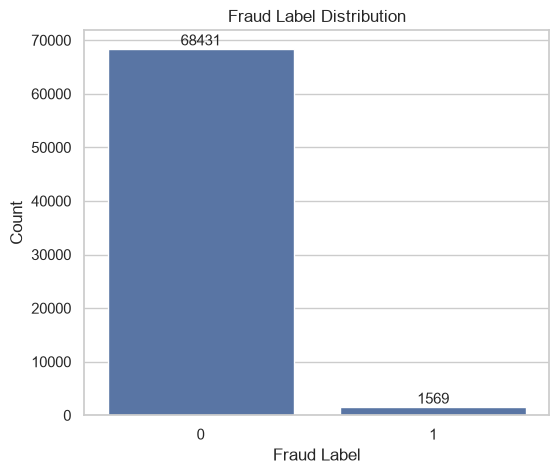

In [22]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df,
    x="fraud_label"
)

ax.bar_label(ax.containers[0])

plt.title("Fraud Label Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Count")

plt.show()

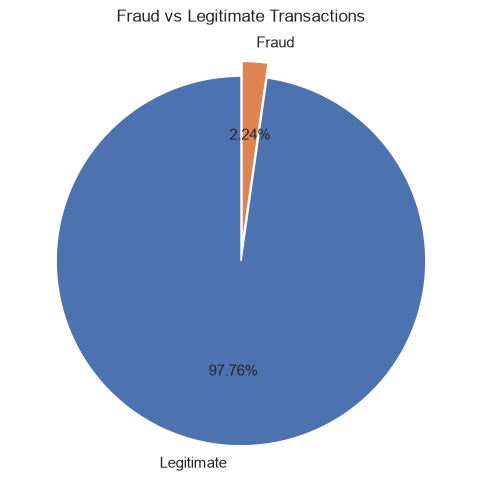

In [23]:
plt.figure(figsize=(6, 6))

plt.pie(
    target_counts,
    labels=["Legitimate", "Fraud"],
    autopct="%1.2f%%",
    explode=[0, 0.08],
    startangle=90
)

plt.title("Fraud vs Legitimate Transactions")

plt.show()

In [24]:
fraud_rate = df["fraud_label"].mean() * 100

print(f"Fraud Rate       : {fraud_rate:.2f}%")
print(f"Legitimate Rate  : {100 - fraud_rate:.2f}%")

Fraud Rate       : 2.24%
Legitimate Rate  : 97.76%
